# Allocazione adattiva con catena di Markov sui regimi di volatilità: risultati sul test

In questo notebook riguardo i risultati del progetto sul periodo di **test (2015-2026)**, che ho guardato una sola
volta dopo aver fissato tutte le scelte sul periodo di sviluppo (fino al 2014). Non ottimizzo nulla qui:
le configurazioni vengono lette da `config_congelata.json` e tutte le serie sono ricalcolate con lo stesso codice
dell'esame (`src/markov_regime_allocation/esame.py`).

La domanda è semplice: usare la probabilità di stress data dalla catena di Markov per ridurre il rischio **aggiunge
qualcosa** rispetto a regole più semplici, come il vol targeting o un'esposizione costante?

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

RADICE = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RADICE / "src"))
from markov_regime_allocation import grafici, multiscala, regimi
from markov_regime_allocation.esame import NOMI_ORDINATI, prepara_esame, simulazioni_complete, tabella_metriche

OUT = RADICE / "output"
cfg = json.loads((RADICE / "config_congelata.json").read_text())
ctx = prepara_esame("test", cfg)          # richiede qualche minuto: HMM e logistica vengono riadattati negli anni
sims = simulazioni_complete(ctx, 5.0)     # costo di 5 punti base sul turnover della parte rischiosa
met = tabella_metriche(ctx, sims)
print("Finestra di test:", ctx.inizio_val.date(), "->", ctx.fine_val.date(), "-", int(ctx.finestra.sum()), "giorni")

Finestra di test: 2015-01-01 -> 2026-06-30 - 2889 giorni


## 1. Quanto rende e quanto rischia ogni regola

Tutte le righe sono al netto dei costi. `esposizione_media` è la quota media investita nel nucleo rischioso
(NoDur, Mkt, Chips, Bond7, Oro); il resto è liquidità. Il vol targeting «a esposizione pari» ha la stessa esposizione
media della strategia multi-scala, così il confronto non premia chi semplicemente rischia meno.

In [2]:
met.round(3)

,sharpe,rendimento,volatilita,drawdown,turnover_annuo,esposizione_media
mercato,0.697,0.140,0.182,-0.342,0.087,0.999
60_40,0.671,0.090,0.106,-0.209,0.225,1.000
nucleo_statico,0.792,0.079,0.073,-0.153,1.550,1.000
esposizione_costante,0.793,0.060,0.049,-0.102,1.040,0.670
vol_target,0.770,0.058,0.048,-0.087,1.705,0.710
vol_target_pari,0.765,0.055,0.045,-0.083,1.634,0.670
trend,0.665,0.056,0.053,-0.084,4.991,0.711
hmm,0.766,0.061,0.052,-0.083,2.422,0.805
logistica,0.768,0.055,0.044,-0.066,2.064,0.678
stato,0.769,0.055,0.044,-0.073,2.285,0.675


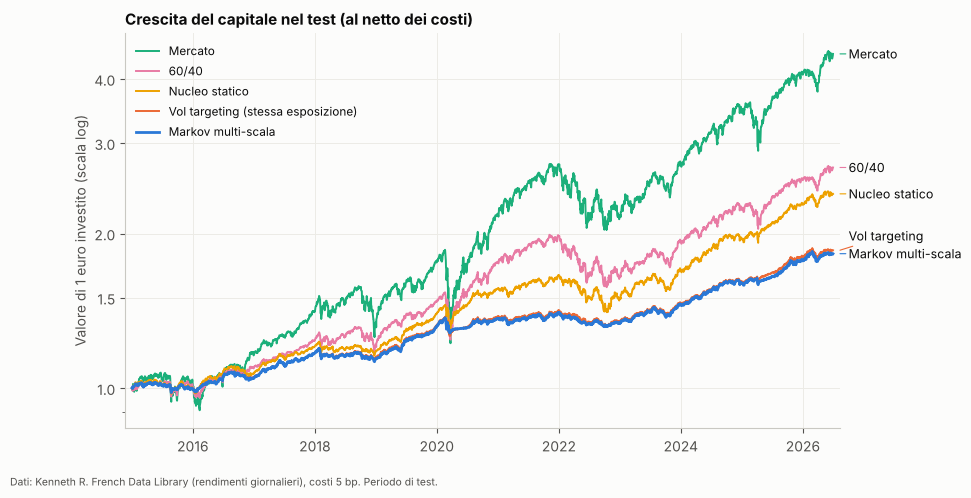

In [3]:
grafici.fig_equity(sims, ctx.finestra)
plt.show()

Le due curve in basso (multi-scala e vol targeting) sono quasi indistinguibili: la parte di rischio è la stessa,
e quindi cresce meno del mercato. Il punto non è battere il mercato in rendimento, ma la perdita che si subisce lungo il
percorso.

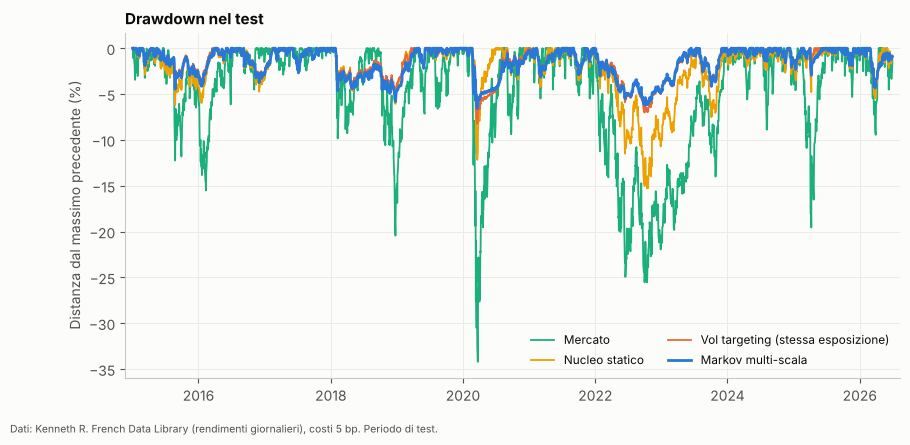

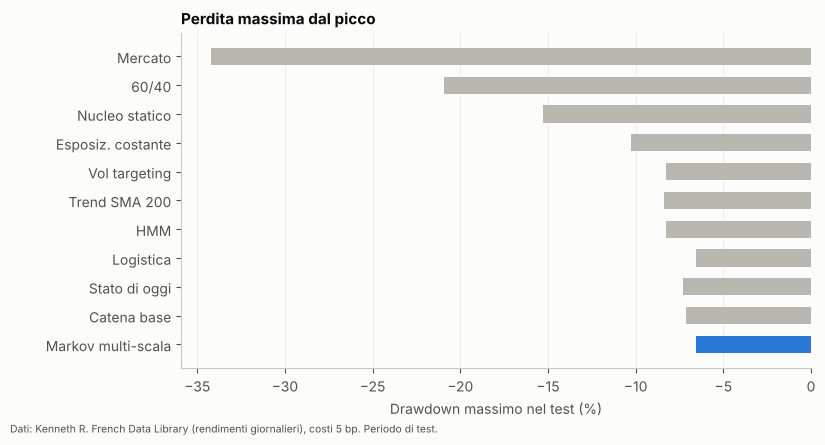

In [4]:
grafici.fig_drawdown(sims, ctx.finestra)
plt.show()
grafici.fig_drawdown_massimo(met, [n for n in NOMI_ORDINATI if n != "vol_target"])
plt.show()

## 2. Cosa fa la strategia nel tempo

La quota investita scende nei periodi di stress (grigio) e risale quando la volatilità si calma. Il vol targeting fa
una cosa molto simile usando solo la volatilità osservata.

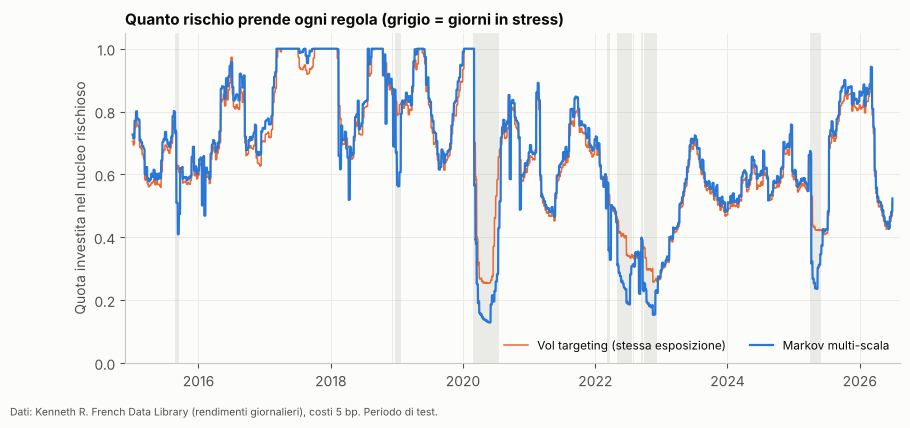

In [5]:
grafici.fig_esposizione(sims, ctx.stati.reindex(ctx.R.index), ctx.finestra)
plt.show()

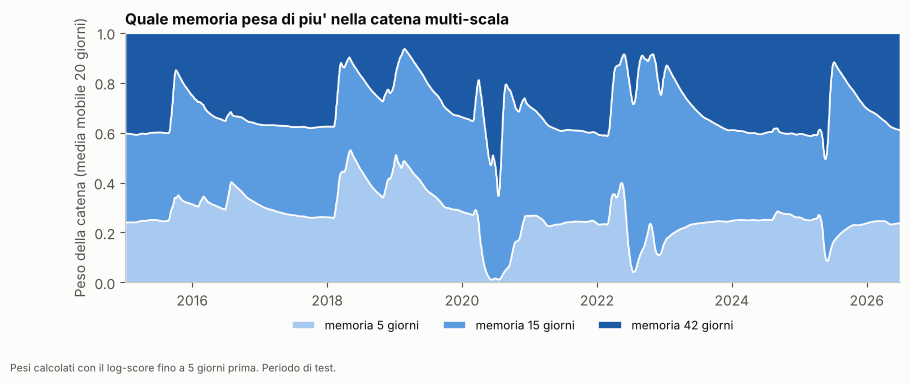

In [6]:
w = multiscala.probabilita_stress_multiscala(ctx.mkt, q_alto=cfg["multi"]["q_alto"])[1].reindex(ctx.R.index)
grafici.fig_pesi_scale(w, ctx.finestra)
plt.show()

La catena multi-scala combina tre catene con memorie di 5, 15 e 42 giorni. I pesi si ricalcolano nel tempo in base a quale
memoria ha previsto meglio lo stress nei giorni passati (sempre con almeno 5 giorni di ritardo, quando l'esito è già noto).

## 3. Differenza con ogni alternativa, con intervallo di incertezza

Differenza di Sharpe e di drawdown massimo tra la multi-scala e ogni confronto, con intervallo al 95% da bootstrap
stazionario (blocchi di lunghezza media 20 giorni). I numeri vengono da `scripts/06_inferenza.py test`.

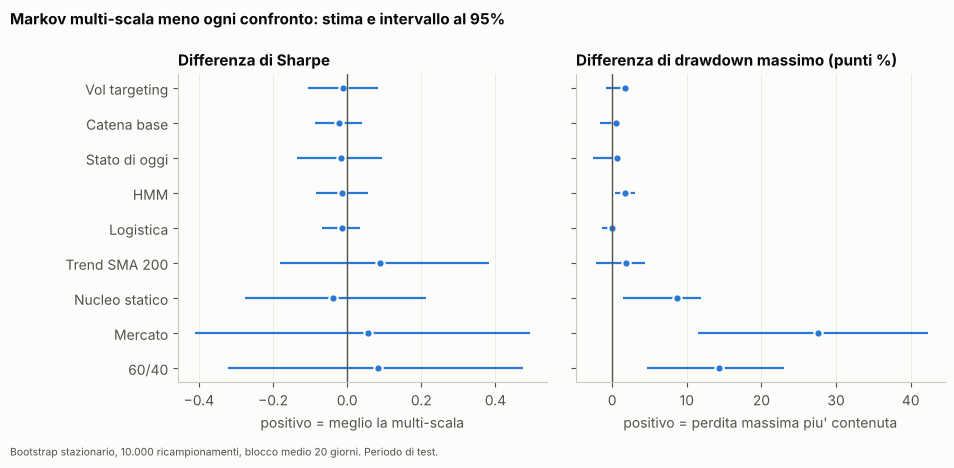

In [7]:
boot = json.loads((OUT / "bootstrap_test.json").read_text())
grafici.fig_forest(boot)
plt.show()

Su Sharpe nessun intervallo esclude lo zero a favore della multi-scala contro le regole basate sulla volatilità
(vol targeting, catena base, HMM, logistica, stato di oggi). Il vantaggio reale e netto è la **riduzione del drawdown
rispetto a mercato, 60/40 e nucleo statico**, che però si ottiene anche con il semplice vol targeting.

Quanto vantaggio poteva riconoscere questo test? Lo stimo con una simulazione: prendo i rendimenti di sviluppo, ricampiono
a blocchi, aggiungo alla strategia un vantaggio di Sharpe noto e conto quante volte l'intervallo lo riconosce.

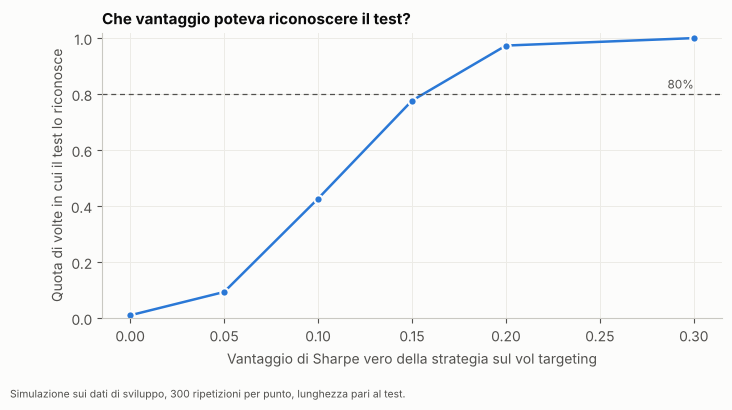

In [8]:
grafici.fig_potenza(pd.read_csv(OUT / "potenza.csv"))
plt.show()

Con la lunghezza di questo test, un vantaggio di Sharpe di circa 0,10 verrebbe riconosciuto meno di una volta su due, uno di
0,15 in circa tre casi su quattro. L'assenza di vantaggio osservata esclude quindi vantaggi grandi, non quelli piccoli.

## 4. I regimi e la catena

La matrice mostra quanto spesso uno stato resta uguale il giorno dopo. I regimi sono molto persistenti, ma la durata reale
dei periodi non segue quella prevista da una catena di ordine 1 (vedi le analisi descrittive più sotto): è il motivo per cui ho
provato anche la versione con più memorie.

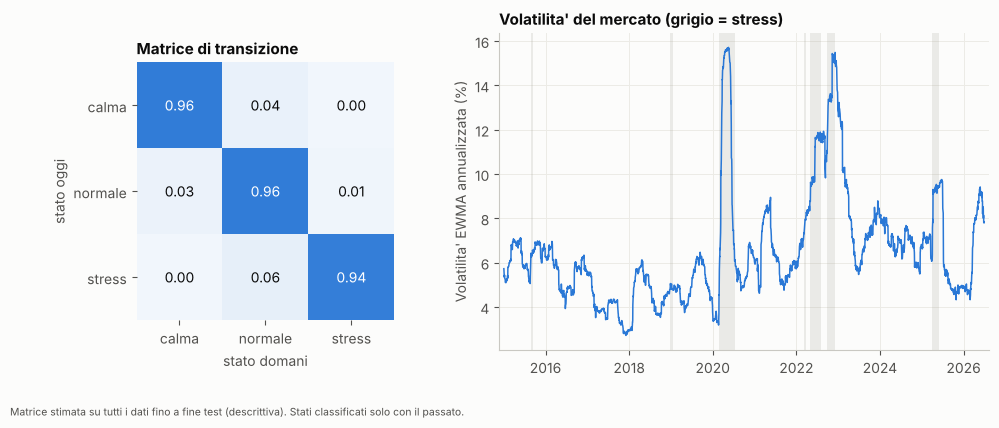

In [9]:
stati_mkt = regimi.stati_as_of(regimi.volatilita_ewma(ctx.mkt), q_alto=0.90)
grafici.fig_regimi(regimi.matrici_transizione(stati_mkt)[-1], ctx.vol, stati_mkt.reindex(ctx.R.index), ctx.finestra)
plt.show()

## 5. Sviluppo contro test

Gli Sharpe di sviluppo sono quelli in cui ho scelto le configurazioni, quindi sono ottimistici per costruzione. Nel test
lo Sharpe delle strategie adattive scende (mercato e 60/40 salgono perché il periodo è stato più favorevole alle azioni) e il
leggero vantaggio di sviluppo della multi-scala sul vol targeting sparisce.

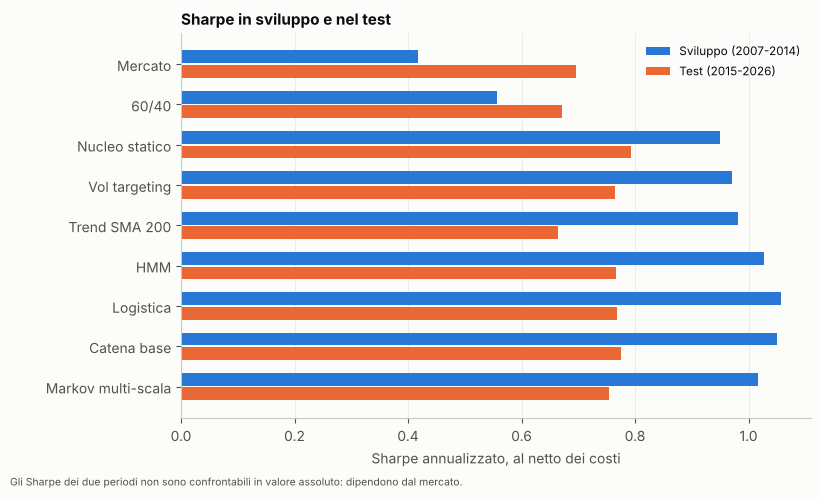

In [10]:
met_sv = pd.read_csv(OUT / "metriche_sviluppo.csv", index_col=0)
nomi_sv = ["mercato", "60_40", "nucleo_statico", "vol_target_pari", "trend", "hmm", "logistica", "base", "multi"]
grafici.fig_sviluppo_test(met_sv, met, nomi_sv)
plt.show()

## 6. La parte previsiva, separata dall'allocazione

Qui misuro solo le previsioni (output di `scripts/10_analisi_descrittive.py`): errore QLIKE sulla varianza a 5 giorni
(più basso è meglio), Brier e log-score sulla probabilità di stress, test di ordine della catena e durata dei regimi
osservata contro quella attesa.

In [11]:
print((OUT / "descrittive.txt").read_text())


===== sviluppo: 2475 giorni di borsa =====
QLIKE medio su 2475 giorni (piu' basso = meglio)
  multi  0.4327
  base   0.4638
  ewma   0.3838
  har    0.3724
Differenza multi - concorrente (negativa = multi meglio), t Newey-West con 2h ritardi:
  contro base  diff=-0.0310  t=-3.58
  contro ewma  diff=+0.0489  t=+2.01
  contro har   diff=+0.0604  t=+3.68
Probabilita' di stress a 5 giorni (evento: stress della scala 15):
  multi        Brier=0.0475  log-score=0.1751
  persistenza  Brier=0.0436  log-score=0.2106
  frequenza    Brier=0.1335  log-score=0.4565
Ordine 1 contro ordine 2 (rapporto di verosimiglianza): LR=119.6, gdl=12, p=1.7e-15
Quota di periodi con durata >= 5/20/60 giorni, osservata contro attesa dalla catena:
  calma    osservata [0.457, 0.13, 0.043]  attesa [0.702, 0.187, 0.005]
  normale  osservata [0.448, 0.269, 0.149]  attesa [0.839, 0.435, 0.076]
  stress   osservata [0.19, 0.143, 0.095]  attesa [0.792, 0.329, 0.032]

===== test: 2889 giorni di borsa =====
QLIKE medio su

**Cosa ne ricavo, senza giri di parole:**

- La multi-scala prevede la varianza meglio della catena base, nello sviluppo e nel test, ma non meglio di una semplice
  EWMA e peggio di HAR.
- Come probabilità di stress, nel test ha errori (Brier e log-score) più bassi di persistenza e frequenza; nello sviluppo
  la persistenza ha un Brier migliore.
- La catena di ordine 1 è rifiutata dai dati (test di ordine): molti periodi di stress finiscono prima del previsto, mentre
  quelli lunghi sono più rari ma ci sono.
- Nell'allocazione questo non si traduce in un guadagno di Sharpe rispetto al vol targeting, e il test non può escludere
  vantaggi piccoli.

Il risultato che resta è la riduzione del rischio, non un vantaggio specifico della catena di Markov.